In [1]:
#%pip install librosa music21 numpy matplotlib soundfile
#%pip install pandas

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


df = pd.read_csv("results.csv")

input_folder = "input"


x = []
y = []

for _, row in df.iterrows():
    
    sample = row["sample"] + ".wav"
    true_pitch = row["true_pitch"]

    file_path = os.path.join(input_folder, sample)

    if os.path.exists(file_path):

        y_audio, sr = librosa.load(file_path, sr=16000)

        # MFCC extraction
        mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=13)

        feature = np.mean(mfcc.T, axis=0)

        x.append(feature)
        y.append(true_pitch)

x = np.array(x)
y = np.array(y)

# -----------------------------
# split
# -----------------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    min_samples_split=2,
    min_samples_leaf=1
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.2%}")

Accuracy: 82.71%


In [3]:
'''from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_acc:.2%}")'''

'from sklearn.svm import SVC\nfrom sklearn.metrics import accuracy_score\n\nsvm_model = SVC()\n\nsvm_model.fit(X_train, y_train)\n\ny_pred_svm = svm_model.predict(X_test)\n\nsvm_acc = accuracy_score(y_test, y_pred_svm)\n\nprint(f"SVM Accuracy: {svm_acc:.2%}")'

In [4]:
'''from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_acc:.2%}")'''

'from sklearn.neighbors import KNeighborsClassifier\n\nknn_model = KNeighborsClassifier(n_neighbors=3)\n\nknn_model.fit(X_train, y_train)\n\ny_pred_knn = knn_model.predict(X_test)\n\nknn_acc = accuracy_score(y_test, y_pred_knn)\n\nprint(f"KNN Accuracy: {knn_acc:.2%}")'

In [2]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"MLP Accuracy: {mlp_acc:.2%}")

MLP Accuracy: 54.14%


/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: Runtim

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# scale
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# train
mlp_model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500)

mlp_model.fit(x_train_scaled, y_train)

# predict
y_pred_mlp = mlp_model.predict(x_test_scaled)

# accuracy
s_mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"Scaled MLP Accuracy: {s_mlp_acc:.2%}")

/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Scaled MLP Accuracy: 81.20%


/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [5]:
print(
    f"RandomForestClassifier: {acc:.2%}\n"
    #f"SVM: {svm_acc:.2%}\n"
    #f"KNN: {knn_acc:.2%}\n"
    f"scaled MLP: {s_mlp_acc:.2%}\n"
)

RandomForestClassifier: 82.71%
scaled MLP: 81.20%



In [6]:
df["true_pitch"].value_counts()

true_pitch
54    96
48    96
50    96
52    96
56    96
46    91
44    91
Name: count, dtype: int64

In [7]:
#%pip install scikit-learn

<Axes: >

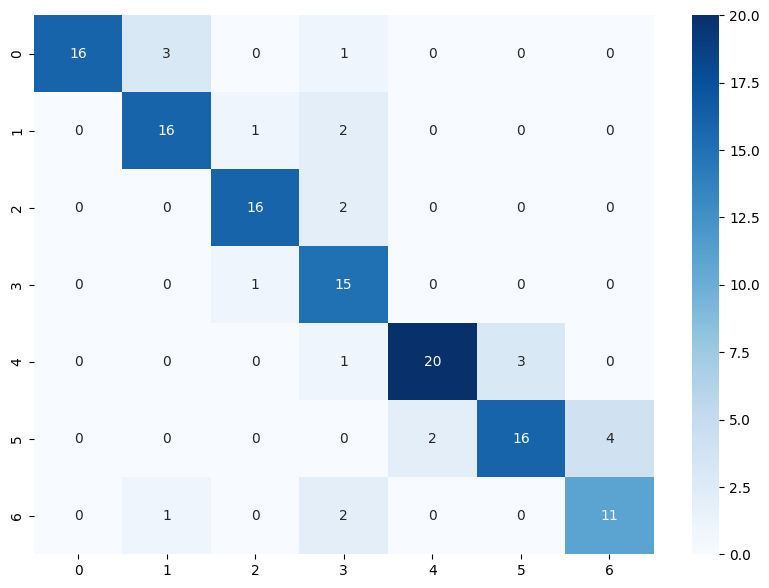

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
